<a href="https://colab.research.google.com/github/Asaf21S/constrained-flow-matching/blob/main/constraints_distillation/notebooks/constrained_gaussian_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
!pip install torchcfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.2 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher, ExactOptimalTransportConditionalFlowMatcher
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import math

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Dataset

In [4]:
RNG = np.random.default_rng()

In [5]:
def get_1d_gaussian_data(peaks: list[tuple[float, float]], n_samples: int, rng=RNG):
    means = np.array([p[0] for p in peaks])
    stds = np.array([p[1] for p in peaks])
    weights = np.full(len(peaks), 1.0 / len(peaks))

    # Pick which peak each sample belongs to
    choices = rng.choice(len(peaks), p=weights, size=n_samples)

    # Generate standard normal samples (mean=0, std=1)
    base_samples = rng.standard_normal(size=n_samples)

    # Scale and shift the base samples
    mixture_samples = (base_samples * stds[choices]) + means[choices]

    return torch.from_numpy(mixture_samples).float()

In [6]:
peaks = [(2, 1), (-2, 2)]
peaks_str = "".join([f"_{mean}_{std}" for mean, std in peaks])

In [7]:
real_data = get_1d_gaussian_data(peaks=peaks, n_samples=100000)

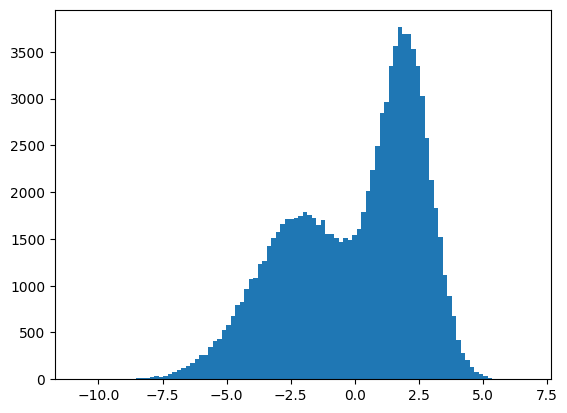

In [8]:
# plot data:
plt.hist(real_data, bins=100)
plt.show()

# General functions

## visualization

In [112]:
def visualize_fm(sampled_data, title="1D Flow Matching Results", alpha=0.5, true_data=None, boundaries=None, center_symmetry=None):
    """
    Visualizes Flow Matching trajectories and final distributions for 1D data.

    Args:
        sampled_data: numpy array of shape [steps, n_samples, 1] or [steps, n_samples]
        title: Title for the final distribution plot
        alpha: Transparency for the histogram
        true_data: Optional numpy array of real target data for comparison
        boundaries: Optional tuple (min_val, max_val) to draw boundary lines
        center_symmetry: Optional float marking the center point of symmetry
    """
    # Safety check: If shape is [steps, n_samples, 1], squeeze it to [steps, n_samples]
    if sampled_data.ndim == 3 and sampled_data.shape[-1] == 1:
        sampled_data = sampled_data.squeeze(-1)

    start_points = sampled_data[0]  # t=0 (Noise)
    end_points = sampled_data[-1]   # t=1 (Generated Data)
    n_steps, n_samples = sampled_data.shape

    # Limit trajectory drawing to 100 lines to keep the plot readable
    n_plot = min(100, n_samples)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ==========================================
    # 1. Flow Plot: Time (t) vs. Position (x)
    # ==========================================
    axes[0].set_title("1D Trajectories Over Time")
    t_values = np.linspace(0, 1, n_steps)

    # Plot trajectories
    axes[0].plot(t_values, sampled_data[:, :n_plot], color='black', alpha=0.15)

    # Mark start and end points
    axes[0].scatter(np.zeros(n_plot), start_points[:n_plot],
                    c='red', s=15, label='Start (Noise, t=0)', zorder=3)
    axes[0].scatter(np.ones(n_plot), end_points[:n_plot],
                    c='blue', s=15, label='End (Data, t=1)', zorder=3)

    # Draw Horizontal boundary lines
    if boundaries is not None:
        min_val, max_val = boundaries
        axes[0].axhline(y=min_val, color='green', linestyle='--', linewidth=2, zorder=4, label='Boundaries')
        axes[0].axhline(y=max_val, color='green', linestyle='--', linewidth=2, zorder=4)

    # Draw Center Symmetry line
    if center_symmetry is not None:
        axes[0].axhline(y=center_symmetry, color='orange', linestyle='-.', linewidth=2, zorder=4, label='Symmetry Center')

    axes[0].set_xlabel("Time (t)")
    axes[0].set_ylabel("Position (x)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ==========================================
    # 2. Final Distribution: Histogram
    # ==========================================
    if boundaries is not None:
        min_val, max_val = boundaries
        inside_count = ((end_points >= min_val) & (end_points <= max_val)).sum()
        title = title + f"\nBoundaries Percentage: {inside_count / n_samples * 100:.2f}%"

    if center_symmetry is not None:
        sorted_ends = np.sort(end_points)
        half_N = n_samples // 2

        left_half = sorted_ends[:half_N]
        right_half_reversed = sorted_ends[-half_N:][::-1]

        sym_mse = np.mean((left_half + right_half_reversed - 2 * center_symmetry) ** 2)

        title = title + f"\nSymmetry MSE: {sym_mse:.5f}"

    axes[1].set_title(title)

    # If you provided the real GMM dataset, plot it in the background
    if true_data is not None:
        if true_data.ndim == 2 and true_data.shape[-1] == 1:
            true_data = true_data.squeeze(-1)

        axes[1].hist(true_data, bins=50, density=True, color='magenta',
                     alpha=0.3, label="Target (True Data)")

    axes[1].hist(end_points, bins=50, density=True, color='blue',
                 alpha=alpha, label="Generated Data")

    # Draw Vertical boundary lines
    if boundaries is not None:
        min_val, max_val = boundaries
        axes[1].axvline(x=min_val, color='green', linestyle='--', linewidth=2, zorder=4, label='Boundaries')
        axes[1].axvline(x=max_val, color='green', linestyle='--', linewidth=2, zorder=4)

    # Draw Center Symmetry line
    if center_symmetry is not None:
        axes[1].axvline(x=center_symmetry, color='orange', linestyle='-.', linewidth=2, zorder=4, label='Symmetry Center')

    axes[1].set_xlabel("Position (x)")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Feature Importance

In [10]:
def calculate_permutation_importance(model, dataloader, criterion, feature_names):
    """
    Calculates permutation feature importance for a model with an arbitrary number of inputs.

    Args:
        model: The trained PyTorch model.
        dataloader: DataLoader containing the validation/test data.
        criterion: The loss function.
        feature_names: List of strings representing the names of the features in order.
    """
    model.eval()

    # Calculate Baseline Loss
    baseline_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            # Move entire batch to device
            batch = [b.to(device) for b in batch]

            # The last element is the target, everything else is a feature
            features = batch[:-1]
            target = batch[-1]

            # Unpack the features list directly into the model arguments
            pred = model(*features)

            # Calculate loss (Ensure target shape matches pred shape!)
            baseline_loss += criterion(pred, target.view_as(pred)).item()

    baseline_loss /= len(dataloader)

    print(f"Baseline MSE Loss: {baseline_loss:.6f}\n")

    # Permute each feature and measure the drop in performance
    importances = {}

    for i, feature_name in enumerate(feature_names):
        permuted_loss = 0.0

        with torch.no_grad():
            for batch in dataloader:
                batch = [b.to(device) for b in batch]
                features = batch[:-1]
                target = batch[-1]

                # Shuffle the chosen feature along the batch dimension
                indices = torch.randperm(features[i].size(0), device=device)
                features[i] = features[i][indices]

                # Pass corrupted features to model using unpacking
                pred = model(*features)

                permuted_loss += criterion(pred, target.view_as(pred)).item()

        permuted_loss /= len(dataloader)

        # Importance = How much worse the loss got
        increase_in_loss = permuted_loss - baseline_loss
        importances[feature_name] = increase_in_loss

        print(f"Shuffled {feature_name:<10} | New Loss: {permuted_loss:.6f} | Error Increase: +{increase_in_loss:.6f}")

    return importances

In [11]:
def plot_feature_importance(importances, save_path="student_feature_importance.png"):
    """
    Creates a professional horizontal bar chart for feature importances.

    Args:
        importances (dict): The dictionary returned by calculate_permutation_importance.
        save_path (str): Where to save the generated image for your README.
    """
    sorted_importances = sorted(importances.items(), key=lambda item: item[1])
    features = [item[0] for item in sorted_importances]
    values = [item[1] for item in sorted_importances]

    plt.figure(figsize=(10, 6))

    bars = plt.barh(features, values, color='#5A9BD5', edgecolor='black', alpha=0.8)

    plt.xlabel("Increase in MSE Loss (Importance)", fontsize=12, labelpad=10)
    plt.title("Permutation Feature Importance", fontsize=14, fontweight='bold', pad=15)

    plt.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)

    for bar in bars:
        width = bar.get_width()
        padding = max(values) * 0.01
        plt.text(
            width + padding,
            bar.get_y() + bar.get_height() / 2,
            f"+{width:.4f}",
            va='center',
            ha='left',
            fontsize=10,
            color='black'
        )

    plt.xlim(0, max(values) * 1.15)

    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {save_path}")

    plt.show()

# Model definition

In [12]:
class FlowMatchingMLP(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        # Input is 2D: [position x_t, time t]
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1) # Output is 1D: velocity
        )

    def forward(self, x, t):
        # x shape: (batch_size, 1), t shape: (batch_size, 1)
        input_features = torch.cat([x, t], dim=-1)
        return self.net(input_features)

# Train loop

In [13]:
# Cache
model = FlowMatchingMLP().to(device)
state_dict = torch.load(f"1d_gmm_peaks_{peaks_str}.pth", map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
# Settings
model = FlowMatchingMLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=0.0)
iterations = 10000
batch_size = 256

loss_list = []

In [ ]:
for step in tqdm(range(iterations)):
    optimizer.zero_grad()
    x1 = get_1d_gaussian_data(peaks, n_samples=batch_size).to(device)  # real data
    x1 = x1.view(-1, 1)
    x0 = torch.randn_like(x1).to(device)  # noise

    # compute loss
    t, xt, real_vt = FM.sample_location_and_conditional_flow(x0, x1)
    t = t.view(-1, 1)
    pred_vt = model(xt, t)
    loss = torch.mean((pred_vt - real_vt) ** 2)
    loss_list.append(loss.item())
    if step % (iterations / 10) == 0:
        print(np.mean(loss_list[step - int(iterations/10):step+1]))

    loss.backward()
    optimizer.step()

  0%|          | 0/10000 [00:00<?, ?it/s]

2.6136081218719482
0.10981416964734142
0.05724947994666083
0.055217184958612914
0.05806793753740626
0.053771803121582105
0.05499047337548359
0.05228703089531039
0.05228021773663196
0.05346042387835034


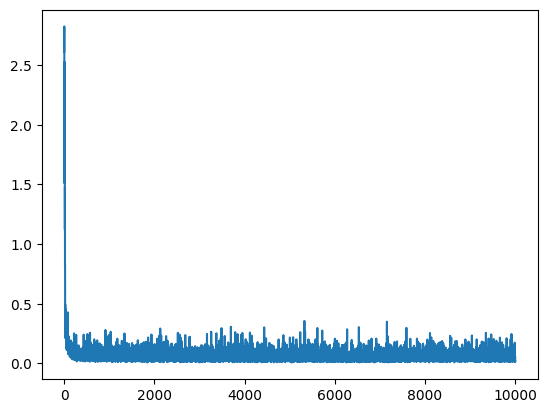

In [ ]:
plt.plot(loss_list)
plt.show()

In [ ]:
torch.save(model.state_dict(), f"1d_gmm_peaks_{peaks_str}.pth")

# Standard Generation

In [14]:
def sample_trajectory(model, n_samples, steps=100):
    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    traj = [x.cpu()]
    model.eval()
    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.full((n_samples, 1), t, device=device)
            v = model(x, t_batch)
            x = x + v * dt
            traj.append(x.cpu())

    return torch.stack(traj).numpy()  # Final shape: [steps + 1, n_samples, 2]

In [15]:
sampled_data_no_constraints = sample_trajectory(model, n_samples=10000)

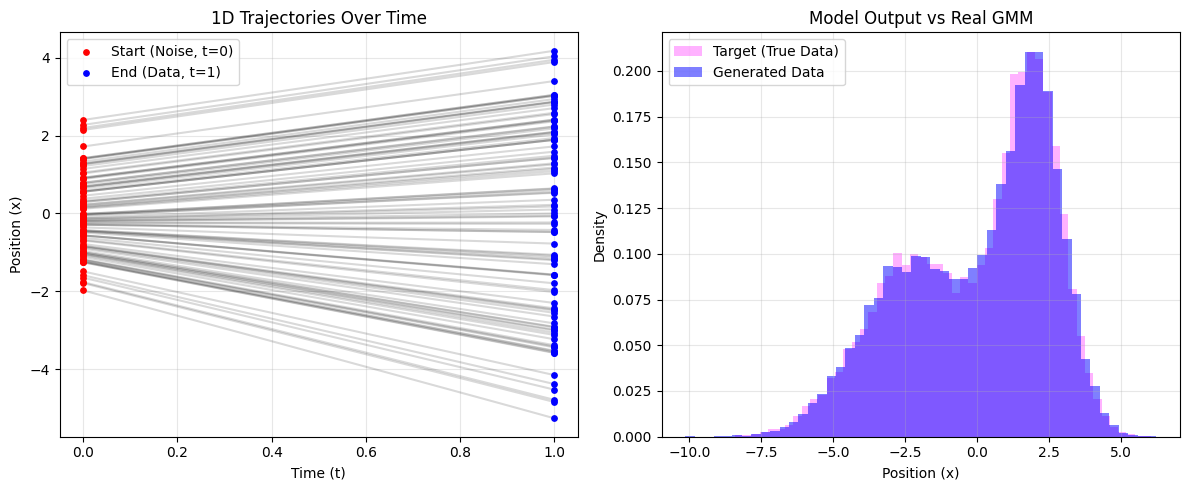

In [16]:
visualize_fm(
    sampled_data=sampled_data_no_constraints,
    true_data=real_data[:10000],
    title="Model Output vs Real GMM"
)

# HardFlow

In [17]:
static_boundary = (-3, 3)
dynamic_boundaries_range = ((-7.5, 0), (0, 5))
ranges_str = "".join([f"_{range_min}_{range_max}" for range_min, range_max in dynamic_boundaries_range])

In [18]:
def sample_trajectory_hardflow(model, n_samples, loss_fn, steps=100, guidance_scale=5.0):
    """
    HardFlow-style guided sampling for 1D Flow Matching.
    """
    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    traj = [x.cpu()]
    model.eval()

    for i in range(steps):
        t = i * dt
        t_batch = torch.full((n_samples, 1), t, device=device)

        x = x.detach().requires_grad_(True)
        v = model(x, t_batch)

        # predict x_1
        x1_hat = x + (1 - t) * v

        # calculate the constraint loss on the predicted destination
        loss = loss_fn(x1_hat).sum()

        # calculate the gradient of the loss w.r.t the current position x_t
        grad = torch.autograd.grad(loss, x)[0]

        # apply guidance
        current_scale = t * guidance_scale
        v_guided = v - current_scale * grad

        x = x.detach() + v_guided.detach() * dt

        traj.append(x.cpu())

    return torch.stack(traj).numpy()  # Final shape: [steps + 1, n_samples, 1]

## loss function 1

In [ ]:
def create_boundary_loss(min_val, max_val):
    """
    Creates a loss function that penalizes points outside [min_val, max_val].
    Uses a squared ReLU to provide smooth, distance-proportional gradients.
    """
    def boundary_loss(x1_hat):
        # Penalty if x1_hat is LESS than min_val
        loss_lower = torch.nn.functional.relu(min_val - x1_hat) ** 2

        # Penalty if x1_hat is GREATER than max_val
        loss_upper = torch.nn.functional.relu(x1_hat - max_val) ** 2

        return loss_lower + loss_upper

    return boundary_loss

In [ ]:
sampled_data_guided = sample_trajectory_hardflow(
    model=model,
    n_samples=10000,
    loss_fn=create_boundary_loss(*static_boundary),
    guidance_scale=1.0
)

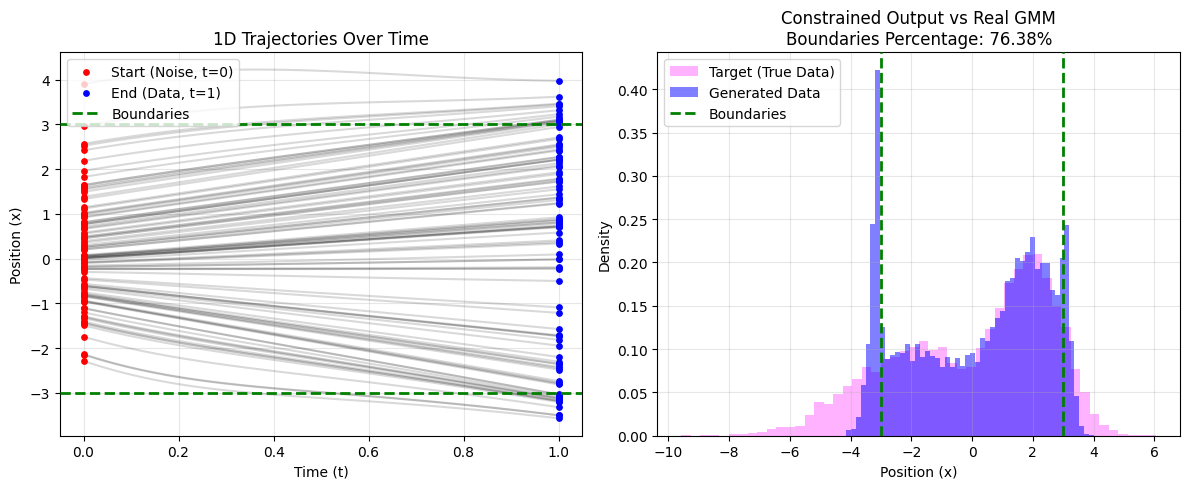

In [ ]:
visualize_fm(
    sampled_data=sampled_data_guided,
    true_data=real_data[:10000],
    title="Constrained Output vs Real GMM",
    boundaries=static_boundary
)

## loss function 2

In [ ]:
def create_exponential_barrier_loss(min_val, max_val, steepness=2.0):
    """
    Creates a smooth exponential barrier.
    steepness controls how sharply the barrier rises.
    """
    def boundary_loss(x1_hat):
        # Repulsion from the lower boundary
        loss_lower = torch.exp(steepness * (min_val - x1_hat))**2

        # Repulsion from the upper boundary
        loss_upper = torch.exp(steepness * (x1_hat - max_val))**2

        return loss_lower + loss_upper

    return boundary_loss

In [ ]:
sampled_data_guided2 = sample_trajectory_hardflow(
    model=model,
    n_samples=10000,
    loss_fn=create_exponential_barrier_loss(*static_boundary, 1.0),
    guidance_scale=0.1
)

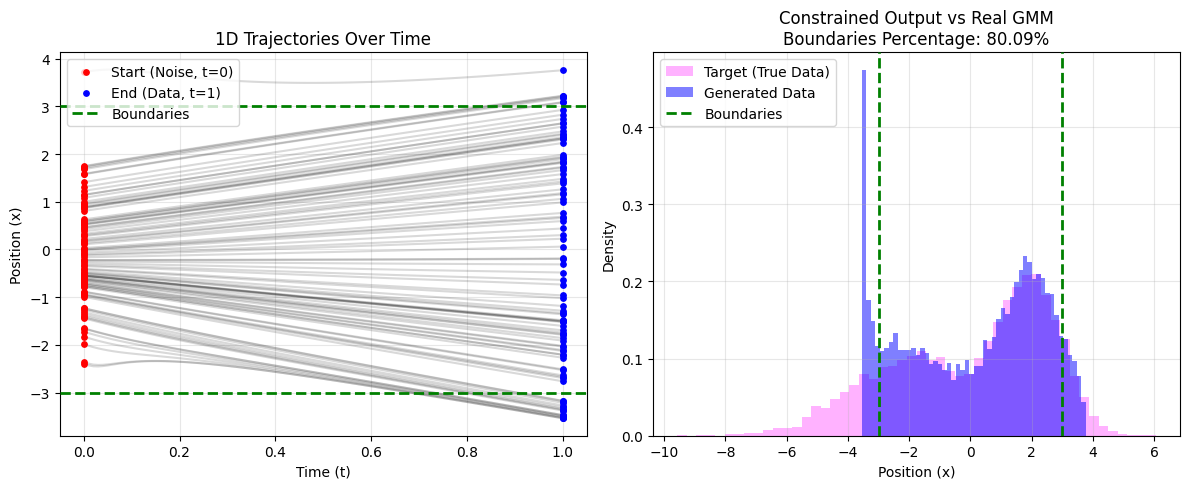

In [ ]:
visualize_fm(
    sampled_data=sampled_data_guided2,
    true_data=real_data[:10000],
    title="Constrained Output vs Real GMM",
    boundaries=static_boundary
)

## loss function 3

In [19]:
def create_softplus_barrier_loss(min_val, max_val, steepness=2.0):
    def boundary_loss(x1_hat):
        # softplus(x) = log(1 + exp(x))
        # It grows smoothly then becomes linear.
        loss_lower = torch.nn.functional.softplus(steepness * (min_val - x1_hat))**2
        loss_upper = torch.nn.functional.softplus(steepness * (x1_hat - max_val))**2

        return loss_lower + loss_upper
    return boundary_loss

In [20]:
sampled_data_guided3 = sample_trajectory_hardflow(
    model=model,
    n_samples=10000,
    loss_fn=create_softplus_barrier_loss(*static_boundary, 1),
    guidance_scale=2
)

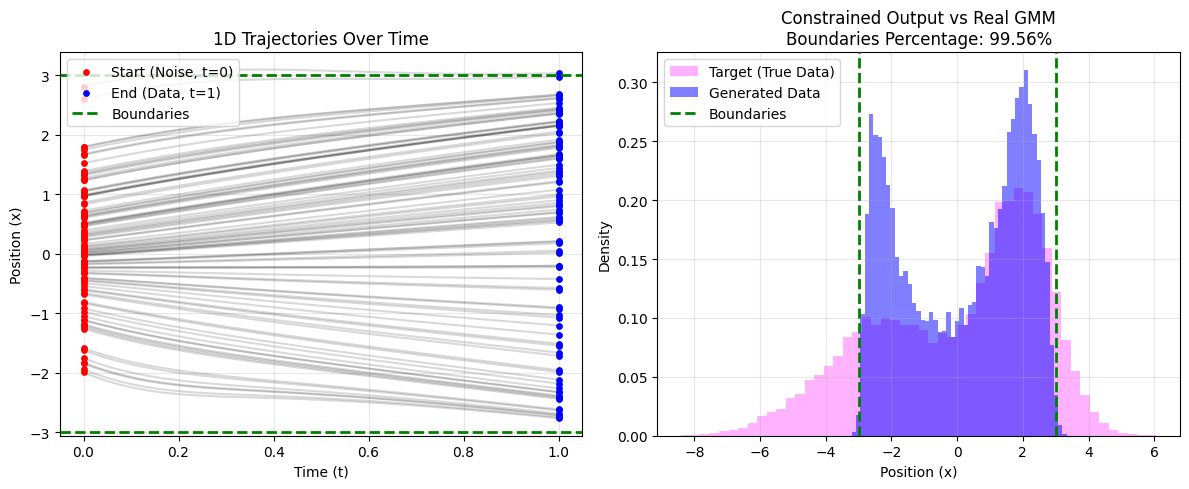

In [21]:
visualize_fm(
    sampled_data=sampled_data_guided3,
    true_data=real_data[:10000],
    title="Constrained Output vs Real GMM",
    boundaries=static_boundary
)

# Distillation - Specific Boundary Constraint

## create dataset for distillation

In [ ]:
# dataset generation
def create_teacher_dataset(model, n_samples, loss_fn, steps=100, guidance_scale=5.0):
    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    all_x = []
    all_t = []
    all_v = []
    all_x1_hat = []
    all_targets = []
    model.eval()

    for i in range(steps):
        t = i * dt
        t_batch = torch.full((n_samples, 1), t, device=device)

        x = x.detach().requires_grad_(True)
        v = model(x, t_batch)

        # predict x_1
        x1_hat = x + (1 - t) * v

        # calculate the constraint loss on the predicted destination
        loss = loss_fn(x1_hat).sum()

        # calculate the gradient of the loss w.r.t the current position x_t
        grad = torch.autograd.grad(loss, x)[0]

        # apply guidance
        v_guided = v - guidance_scale * grad

        # collect data
        all_x.append(x.detach().cpu())
        all_t.append(t_batch.cpu())
        all_v.append(v.detach().cpu())
        all_x1_hat.append(x1_hat.detach().cpu())
        all_targets.append(grad.detach().cpu())

        x = x.detach() + v_guided.detach() * dt

    features = {
        "x": torch.cat(all_x, dim=0),
        "t": torch.cat(all_t, dim=0),
        "v": torch.cat(all_v, dim=0),
        "x1_hat": torch.cat(all_x1_hat, dim=0)
    }
    targets = torch.cat(all_targets, dim=0)
    return features, targets

In [ ]:
features, targets = create_teacher_dataset(
    model=model,
    n_samples=10000,
    loss_fn=create_softplus_barrier_loss(-10, 5, 1),
    guidance_scale=0.5
)

In [ ]:
# split train/val
total_samples = targets.shape[0]
split_ratio = 0.90 # 90% Train, 10% Val
split_idx = int(total_samples * split_ratio)

indices = torch.randperm(total_samples)
train_idx = indices[:split_idx]
val_idx = indices[split_idx:]

train_features = {k: v[train_idx] for k, v in features.items()}
val_features = {k: v[val_idx] for k, v in features.items()}

train_targets = targets[train_idx]
val_targets = targets[val_idx]

In [ ]:
norm_stats = {}

for key in train_features.keys():
    mean = train_features[key].mean()
    std = train_features[key].std() + 1e-8  # prevents divide-by-zero

    norm_stats[key] = {'mean': mean, 'std': std}

    # Apply to BOTH Train and Val using the Train stats
    train_features[key] = (train_features[key] - mean) / std
    val_features[key] = (val_features[key] - mean) / std

for key, stats in norm_stats.items():
    print(f"{key}: mean={stats['mean']:.4f}, std={stats['std']:.4f}")

x: mean=-0.4652, std=2.9948
t: mean=0.4952, std=0.2887
v: mean=-0.9830, std=3.9580
x1_hat: mean=-0.9777, std=4.7993


In [ ]:
train_dataset = TensorDataset(
    train_features['x'], train_features['t'],
    train_features['v'], train_features['x1_hat'],
    train_targets
)

val_dataset = TensorDataset(
    val_features['x'], val_features['t'],
    val_features['v'], val_features['x1_hat'],
    val_targets
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

Train samples: 900000 | Val samples: 100000


## define the student model

In [ ]:
class StudentGuidanceMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # Input features: x (1), t (1), v (1), x1_hat (1) = Total 4
        self.net = nn.Sequential(
            nn.Linear(4, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, t, v, x1_hat):
        inputs = torch.cat([x, t, v, x1_hat], dim=-1)  # [batch_size, 4]
        return self.net(inputs)

## train the student model

In [ ]:
# Cache
student_model = StudentGuidanceMLP().to(device)
state_dict = torch.load(f"1d_gmm_peaks_{peaks_str}_student_static_boundary_|-10_5|.pth", map_location=device)
student_model.load_state_dict(state_dict)

In [ ]:
student_model = StudentGuidanceMLP().to(device)
optimizer = torch.optim.Adam(student_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 25

student_model.train()
train_loss_list = []
val_loss_list = []

print("Starting Student Training...")

for epoch in tqdm(range(epochs)):
    student_model.train()
    train_loss = 0.0
    for batch_x, batch_t, batch_v, batch_x1_hat, batch_target in train_loader:
        batch_x = batch_x.to(device)
        batch_t = batch_t.to(device)
        batch_v = batch_v.to(device)
        batch_x1_hat = batch_x1_hat.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()
        pred_grad = student_model(batch_x, batch_t, batch_v, batch_x1_hat)
        loss = criterion(pred_grad, batch_target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    student_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_t, batch_v, batch_x1_hat, batch_target in val_loader:
            batch_x = batch_x.to(device)
            batch_t = batch_t.to(device)
            batch_v = batch_v.to(device)
            batch_x1_hat = batch_x1_hat.to(device)
            batch_target = batch_target.to(device)

            pred_grad = student_model(batch_x, batch_t, batch_v, batch_x1_hat)
            loss = criterion(pred_grad, batch_target)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)

    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

print("Distillation Complete!")

Starting Student Training...


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 0/25 | Train Loss: 0.100163 | Val Loss: 0.001295
Epoch 5/25 | Train Loss: 0.000931 | Val Loss: 0.000168
Epoch 10/25 | Train Loss: 0.000628 | Val Loss: 0.000092
Epoch 15/25 | Train Loss: 0.000421 | Val Loss: 0.000247
Epoch 20/25 | Train Loss: 0.000432 | Val Loss: 0.000173
Epoch 24/25 | Train Loss: 0.000456 | Val Loss: 0.000501
Distillation Complete!


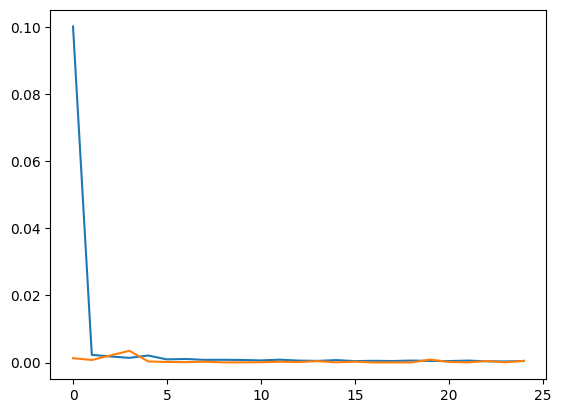

In [ ]:
plt.plot(train_loss_list)
plt.plot(val_loss_list)
plt.show()

In [ ]:
torch.save(student_model.state_dict(), f"1d_gmm_peaks_{peaks_str}_student_static_boundary_|-10_5|.pth")

## sample using the student model

In [ ]:
def sample_trajectory_distilled_hardflow(model, n_samples, steps=100, guidance_scale=5.0):
    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    traj = [x.cpu()]
    model.eval()

    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.full((n_samples, 1), t, device=device)

            v = model(x, t_batch)
            x1_hat = x + (1 - t) * v

            x_norm = (x - norm_stats['x']['mean']) / norm_stats['x']['std']
            t_batch_norm = (t_batch - norm_stats['t']['mean']) / norm_stats['t']['std']
            v_norm = (v - norm_stats['v']['mean']) / norm_stats['v']['std']
            x1_hat_norm = (x1_hat - norm_stats['x1_hat']['mean']) / norm_stats['x1_hat']['std']

            pred_grad = student_model(x_norm, t_batch_norm, v_norm, x1_hat_norm)

            v_guided = v - guidance_scale * pred_grad

            x = x + v_guided * dt

            traj.append(x.cpu())

    return torch.stack(traj).numpy()  # Final shape: [steps + 1, n_samples, 1]

In [ ]:
sampled_data_guided_distilled = sample_trajectory_distilled_hardflow(
    model=model,
    n_samples=10000,
    guidance_scale=0.5
)

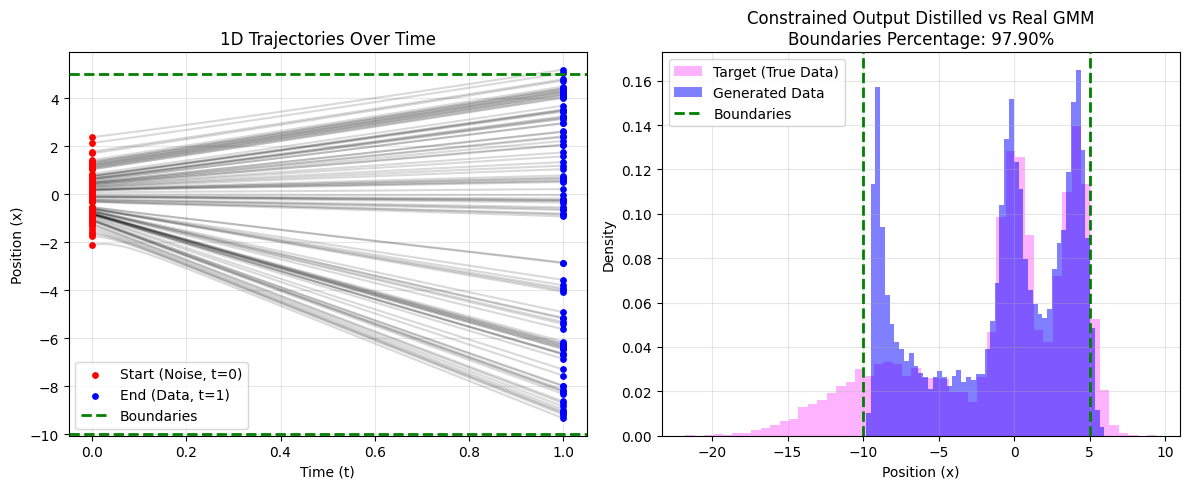

In [ ]:
visualize_fm(
    sampled_data=sampled_data_guided_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Distilled vs Real GMM",
    boundaries=(-10, 5)
)

In [ ]:
importances = calculate_permutation_importance(student_model, val_loader, criterion)

Baseline MSE Loss: 0.000501

Shuffled x      | New Loss: 5.068724 | Error Increase: +5.068222
Shuffled t      | New Loss: 0.358785 | Error Increase: +0.358284
Shuffled v      | New Loss: 1.576381 | Error Increase: +1.575879
Shuffled x1_hat | New Loss: 1.825166 | Error Increase: +1.824664


# Distillation - Dynamic Boundary Constraint

## create dataset for distillation

In [22]:
def create_conditional_teacher_dataset(model, n_samples, min_range, max_range, steepness=2.0, steps=100, guidance_scale=5.0):
    """
    Generates a dataset where every single sample has its own unique, randomized boundary constraints.
    """
    # Randomly sample min_vals and max_vals for every point in the batch
    min_bounds = torch.empty(n_samples, 1, device=device).uniform_(*min_range)
    max_bounds = torch.empty(n_samples, 1, device=device).uniform_(*max_range)

    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    all_x, all_t, all_v, all_x1_hat = [], [], [], []
    all_x1_dist_left, all_x1_dist_right = [], []
    all_targets = []

    model.eval()

    for i in range(steps):
        t = i * dt
        t_batch = torch.full((n_samples, 1), t, device=device)

        x = x.detach().requires_grad_(True)
        v = model(x, t_batch)

        # Predict destination
        x1_hat = x + (1 - t) * v

        # Softplus applied to the batched tensors
        loss_lower = torch.nn.functional.softplus(steepness * (min_bounds - x1_hat)) ** 2
        loss_upper = torch.nn.functional.softplus(steepness * (x1_hat - max_bounds)) ** 2

        loss = (loss_lower + loss_upper).sum()

        # calculate the gradient...
        grad = torch.autograd.grad(loss, x)[0]

        current_scale = t * guidance_scale
        v_guided = v - (current_scale * grad)

        # Feature Engineering
        x1_dist_left = x1_hat - min_bounds
        x1_dist_right = max_bounds - x1_hat

        # Collect data
        all_x.append(x.detach().cpu())
        all_t.append(t_batch.cpu())
        all_v.append(v.detach().cpu())
        all_x1_hat.append(x1_hat.detach().cpu())
        all_x1_dist_left.append(x1_dist_left.detach().cpu())
        all_x1_dist_right.append(x1_dist_right.detach().cpu())
        all_targets.append(grad.detach().cpu())

        x = x.detach() + v_guided.detach() * dt

    inside_bounds = (x >= min_bounds) & (x <= max_bounds)
    accuracy = inside_bounds.float().mean().item() * 100.0
    print(f"Teacher Baseline Accuracy: {accuracy:.2f}% of generated points stayed within their unique boundaries.")

    features = {
        "x": torch.cat(all_x, dim=0),
        "t": torch.cat(all_t, dim=0),
        "v": torch.cat(all_v, dim=0),
        "x1_hat": torch.cat(all_x1_hat, dim=0),
        "x1_dist_left": torch.cat(all_x1_dist_left, dim=0),
        "x1_dist_right": torch.cat(all_x1_dist_right, dim=0)
    }

    targets = torch.cat(all_targets, dim=0)

    return features, targets

In [23]:
features, targets = create_conditional_teacher_dataset(
    model=model,
    n_samples=10000,
    min_range=dynamic_boundaries_range[0],
    max_range=dynamic_boundaries_range[1],
    steepness=1.0,
    guidance_scale=2.0
)

Teacher Baseline Accuracy: 96.78% of generated points stayed within their unique boundaries.


In [24]:
# split train/val
total_samples = targets.shape[0]
split_ratio = 0.90 # 90% Train, 10% Val
split_idx = int(total_samples * split_ratio)

indices = torch.randperm(total_samples)
train_idx = indices[:split_idx]
val_idx = indices[split_idx:]

train_features = {k: v[train_idx] for k, v in features.items()}
val_features = {k: v[val_idx] for k, v in features.items()}

train_targets = targets[train_idx]
val_targets = targets[val_idx]

In [25]:
norm_stats = {}

for key in train_features.keys():
    mean = train_features[key].mean()
    std = train_features[key].std() + 1e-8  # prevents divide-by-zero

    norm_stats[key] = {'mean': mean, 'std': std}

    # Apply to BOTH Train and Val using the Train stats
    train_features[key] = (train_features[key] - mean) / std
    val_features[key] = (val_features[key] - mean) / std

for key, stats in norm_stats.items():
    print(f"{key}: mean={stats['mean']:.4f}, std={stats['std']:.4f}")

x: mean=0.0174, std=1.4388
t: mean=0.4950, std=0.2887
v: mean=0.0942, std=1.3588
x1_hat: mean=0.0591, std=2.1377
x1_dist_left: mean=3.8311, std=2.9112
x1_dist_right: mean=2.4140, std=2.4651


In [26]:
feature_names = list(train_features.keys())
print(f"Features loaded in this order: {feature_names}")

train_dataset = TensorDataset(
    *[train_features[feat] for feat in feature_names],
    train_targets
)

val_dataset = TensorDataset(
    *[val_features[feat] for feat in feature_names],
    val_targets
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

Features loaded in this order: ['x', 't', 'v', 'x1_hat', 'x1_dist_left', 'x1_dist_right']
Train samples: 900000 | Val samples: 100000


## define the student model

In [27]:
class DynamicStudentGuidanceMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, t, v, x1_hat, x1_dist_left, x1_dist_right):
        inputs = torch.cat([x, t, v, x1_hat, x1_dist_left, x1_dist_right], dim=-1)  # [batch_size, 6]
        return self.net(inputs)

## train the student model

In [28]:
# Cache
dynamic_student_model = DynamicStudentGuidanceMLP().to(device)
state_dict = torch.load(f"1d_gmm_peaks_{peaks_str}_student_dynamic_boundaries_range_{ranges_str}.pth", map_location=device)
dynamic_student_model.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
dynamic_student_model = DynamicStudentGuidanceMLP().to(device)
optimizer = torch.optim.Adam(dynamic_student_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 25

dynamic_student_model.train()
train_loss_list = []
val_loss_list = []

print("Starting Dynamic-Student Training...")

for epoch in tqdm(range(epochs)):
    dynamic_student_model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = [b.to(device) for b in batch]

        features = batch[:-1]
        batch_target = batch[-1]

        optimizer.zero_grad()
        pred_grad = dynamic_student_model(*features)
        loss = criterion(pred_grad, batch_target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    dynamic_student_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = [b.to(device) for b in batch]

            features = batch[:-1]
            batch_target = batch[-1]

            pred_grad = dynamic_student_model(*features)
            loss = criterion(pred_grad, batch_target)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)

    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

print("Distillation Complete!")

Starting Dynamic-Student Training...


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 0/25 | Train Loss: 0.047912 | Val Loss: 0.004122
Epoch 5/25 | Train Loss: 0.000493 | Val Loss: 0.000130
Epoch 10/25 | Train Loss: 0.000602 | Val Loss: 0.000086
Epoch 15/25 | Train Loss: 0.000268 | Val Loss: 0.000549
Epoch 20/25 | Train Loss: 0.000169 | Val Loss: 0.000057
Epoch 24/25 | Train Loss: 0.000197 | Val Loss: 0.000042
Distillation Complete!


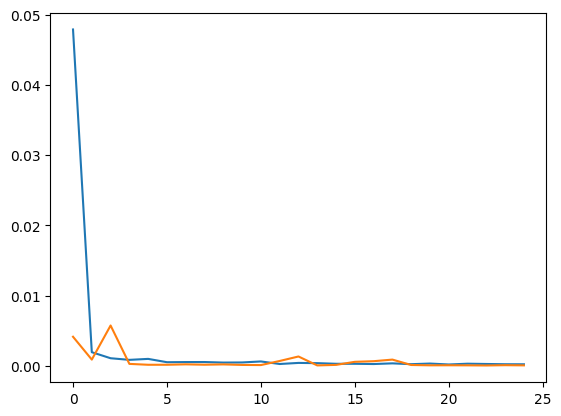

In [ ]:
plt.plot(train_loss_list)
plt.plot(val_loss_list)
plt.show()

In [ ]:
torch.save(dynamic_student_model.state_dict(), f"1d_gmm_peaks_{peaks_str}_student_dynamic_boundaries_range_{ranges_str}.pth")

## sample using the student model

In [29]:
def sample_trajectory_dynamic_distilled_hardflow(model, student_model, boundaries, feature_names, norm_stats, n_samples, steps=100, guidance_scale=5.0):
    """
    Dynamic distilled HardFlow sampling with Linear Guidance Scheduling.

    Args:
        feature_names: A list of strings defining the EXACT order of features the student expects
        norm_stats: The dictionary containing 'mean' and 'std' for all features and the 'target'.
    """
    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    traj = [x.cpu()]
    model.eval()
    student_model.eval()

    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.full((n_samples, 1), t, device=device)

            v = model(x, t_batch)
            x1_hat = x + (1 - t) * v

            raw_features = {
                'x': x,
                't': t_batch,
                'v': v,
                'x1_hat': x1_hat,
                'x1_dist_left': x1_hat - boundaries[0],
                'x1_dist_right': boundaries[1] - x1_hat
            }

            normalized_inputs = []
            for feat in feature_names:
                val = raw_features[feat]
                mean = norm_stats[feat]['mean']
                std = norm_stats[feat]['std']
                normalized_inputs.append((val - mean) / std)

            pred_grad = student_model(*normalized_inputs)

            current_scale = t * guidance_scale
            v_guided = v - (current_scale * pred_grad)

            x = x + v_guided * dt

            traj.append(x.cpu())

    return torch.stack(traj).numpy()  # Final shape: [steps + 1, n_samples, 1]

In [30]:
active_features = ['x', 't', 'v', 'x1_hat', 'x1_dist_left', 'x1_dist_right']

In [31]:
boundaries = (-3.0, 3.0)

sampled_data_guided_dynamic_distilled = sample_trajectory_dynamic_distilled_hardflow(
    model=model,
    student_model=dynamic_student_model,
    boundaries=boundaries,
    feature_names=active_features,
    norm_stats=norm_stats,
    n_samples=10000,
    guidance_scale=2.0
)

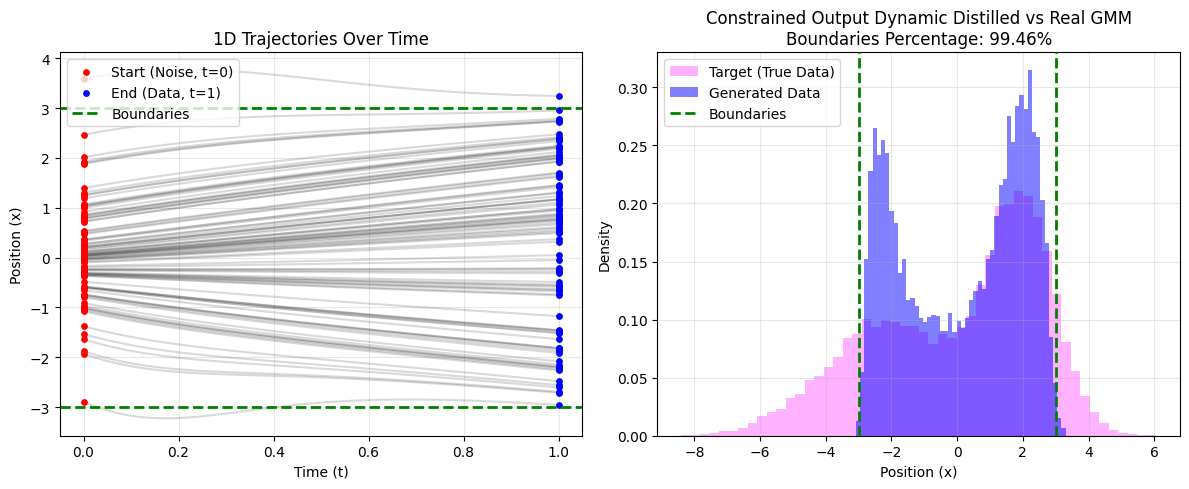

In [32]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Distilled vs Real GMM",
    boundaries=boundaries
)

In [33]:
boundaries = (-2.0, 4.0)

sampled_data_guided_dynamic_distilled = sample_trajectory_dynamic_distilled_hardflow(
    model=model,
    student_model=dynamic_student_model,
    boundaries=boundaries,
    feature_names=active_features,
    norm_stats=norm_stats,
    n_samples=10000,
    guidance_scale=2.0
)

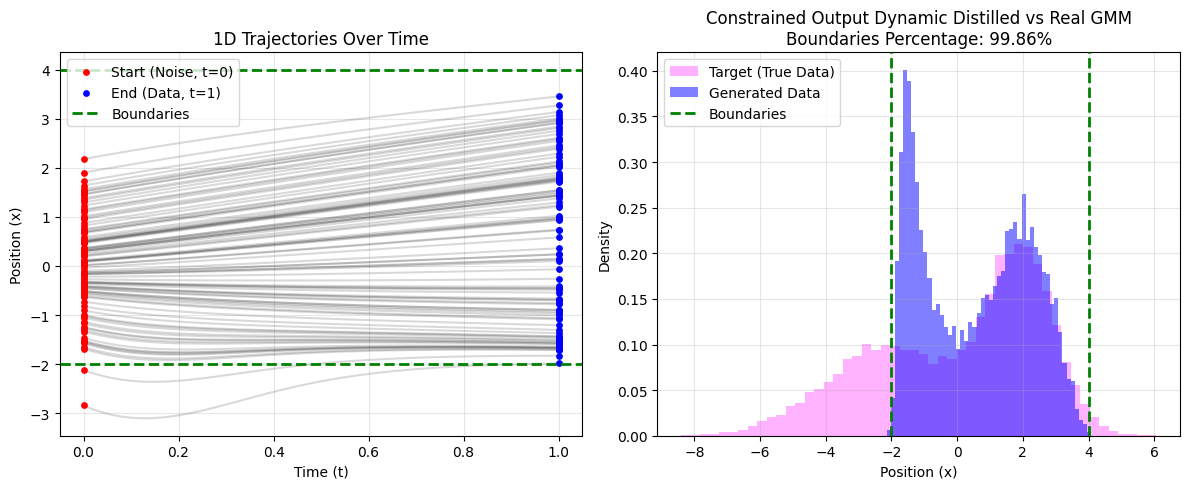

In [34]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Distilled vs Real GMM",
    boundaries=boundaries
)

In [35]:
boundaries = (-7.0, 2.0)

sampled_data_guided_dynamic_distilled = sample_trajectory_dynamic_distilled_hardflow(
    model=model,
    student_model=dynamic_student_model,
    boundaries=boundaries,
    feature_names=active_features,
    norm_stats=norm_stats,
    n_samples=10000,
    guidance_scale=2.0
)

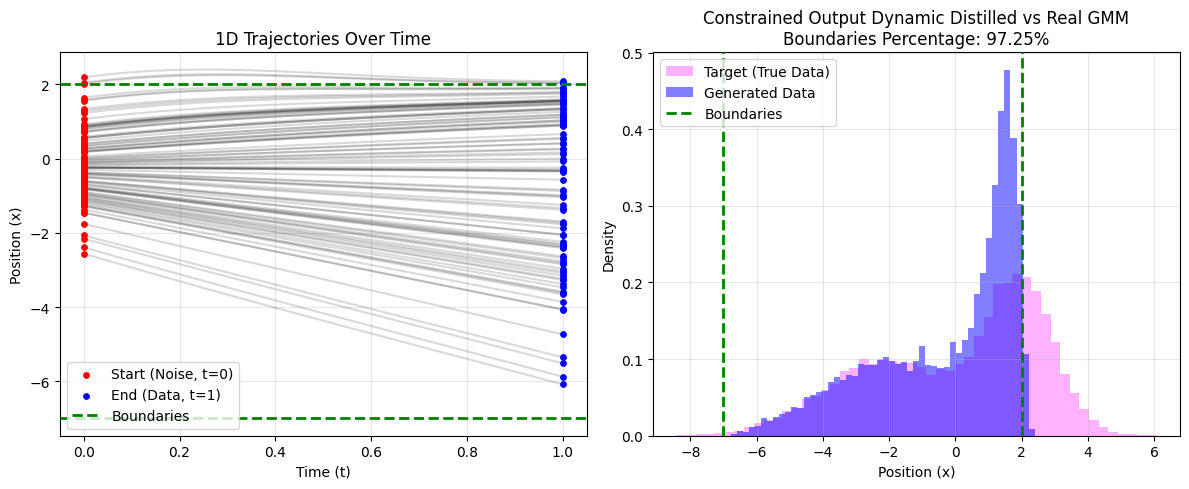

In [36]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Distilled vs Real GMM",
    boundaries=boundaries
)

In [37]:
boundaries = (-2.0, 2.0)

sampled_data_guided_dynamic_distilled = sample_trajectory_dynamic_distilled_hardflow(
    model=model,
    student_model=dynamic_student_model,
    boundaries=boundaries,
    feature_names=active_features,
    norm_stats=norm_stats,
    n_samples=10000,
    guidance_scale=2.0
)

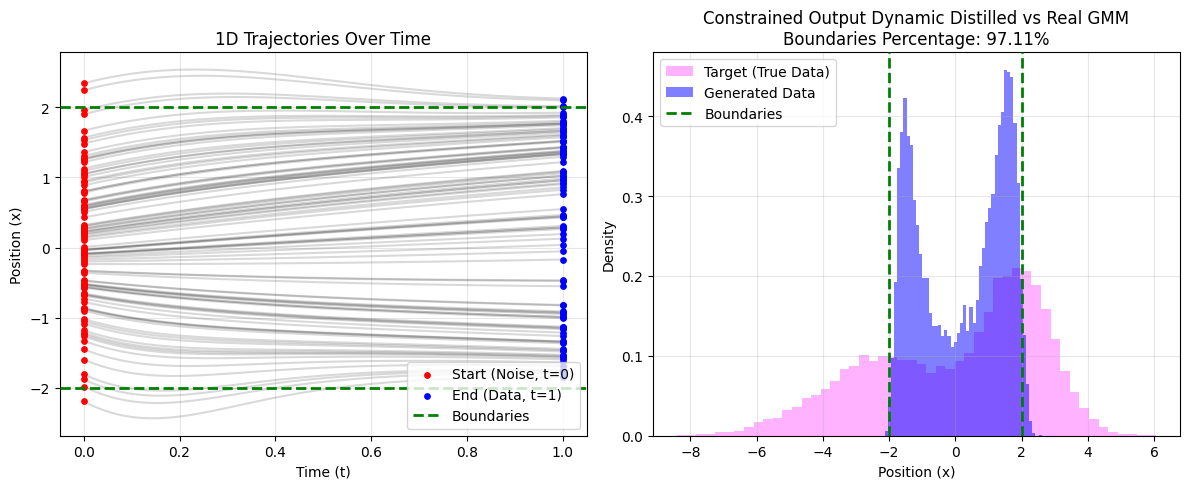

In [38]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Distilled vs Real GMM",
    boundaries=boundaries
)

In [39]:
boundaries = (0.0, 3.0)

sampled_data_guided_dynamic_distilled = sample_trajectory_dynamic_distilled_hardflow(
    model=model,
    student_model=dynamic_student_model,
    boundaries=boundaries,
    feature_names=active_features,
    norm_stats=norm_stats,
    n_samples=10000,
    guidance_scale=2.0
)

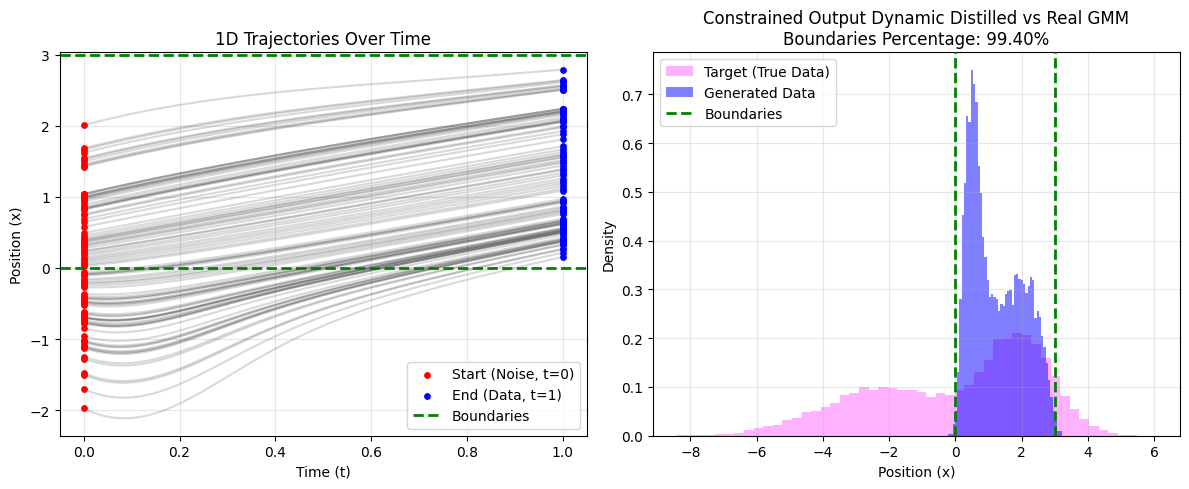

In [40]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Distilled vs Real GMM",
    boundaries=boundaries
)

In [41]:
boundaries = (-3.0, 0.0)

sampled_data_guided_dynamic_distilled = sample_trajectory_dynamic_distilled_hardflow(
    model=model,
    student_model=dynamic_student_model,
    boundaries=boundaries,
    feature_names=active_features,
    norm_stats=norm_stats,
    n_samples=10000,
    guidance_scale=2.0
)

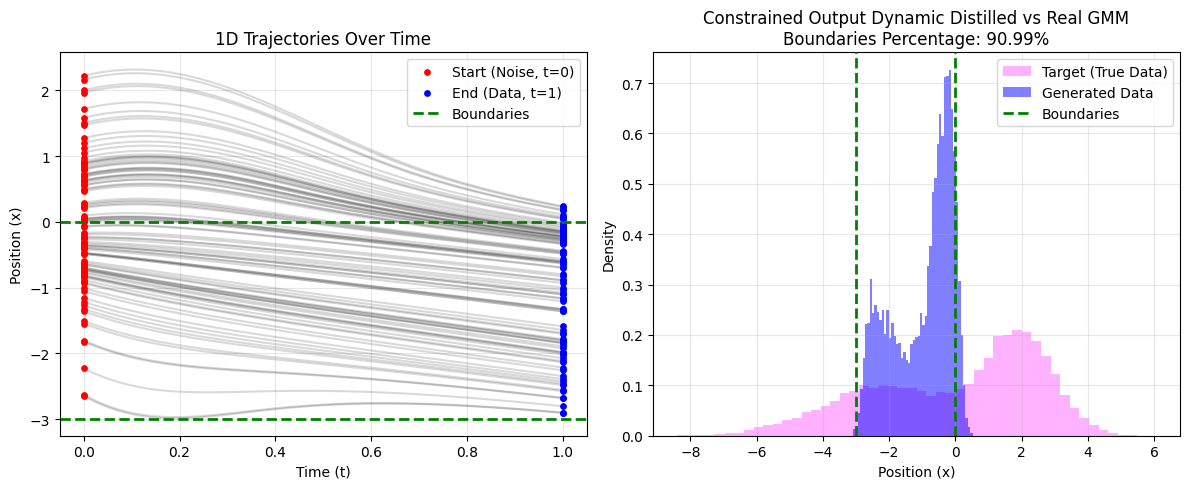

In [42]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Distilled vs Real GMM",
    boundaries=boundaries
)

In [43]:
boundaries = (-1.0, 1.0)

sampled_data_guided_dynamic_distilled = sample_trajectory_dynamic_distilled_hardflow(
    model=model,
    student_model=dynamic_student_model,
    boundaries=boundaries,
    feature_names=active_features,
    norm_stats=norm_stats,
    n_samples=10000,
    guidance_scale=2.0
)

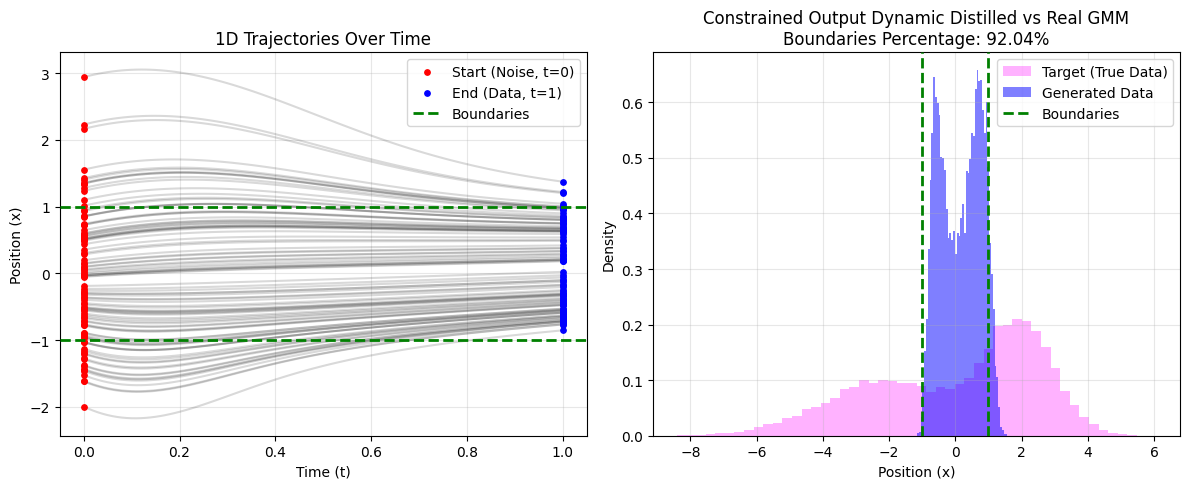

In [44]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Distilled vs Real GMM",
    boundaries=boundaries
)

In [47]:
criterion = nn.MSELoss()
importances = calculate_permutation_importance(dynamic_student_model, val_loader, criterion, feature_names=active_features)

Baseline MSE Loss: 0.000983

Shuffled x          | New Loss: 7.226133 | Error Increase: +7.225150
Shuffled t          | New Loss: 0.252793 | Error Increase: +0.251810
Shuffled v          | New Loss: 0.831698 | Error Increase: +0.830715
Shuffled x1_hat     | New Loss: 1.589926 | Error Increase: +1.588943
Shuffled x1_dist_left | New Loss: 5.232240 | Error Increase: +5.231256
Shuffled x1_dist_right | New Loss: 2.458108 | Error Increase: +2.457125


Plot saved to student_feature_importance.png


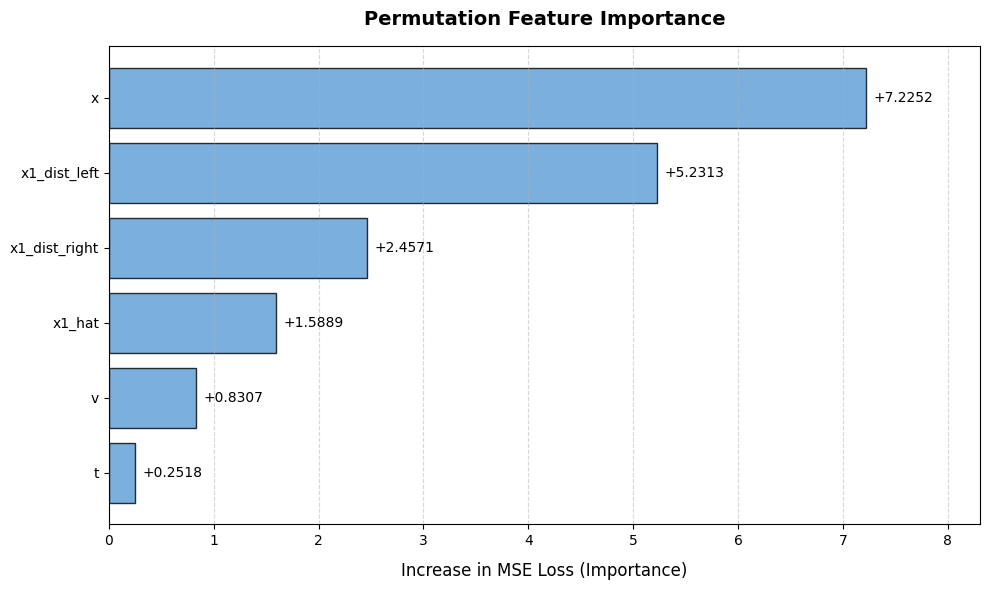

In [48]:
plot_feature_importance(importances)

# Symmetry Constraint

In [64]:
static_center = 0
dynamic_center_range = (-3, 3)
center_range_str = f"_{dynamic_center_range[0]}_{dynamic_center_range[1]}"

In [65]:
def create_symmetry_loss(center_c):
    """
    Creates a distribution-level loss that penalizes asymmetry
    around a defined center point 'center_c'.
    """
    def symmetry_loss(x1_hat_batch):
        # x1_hat_batch: [Batch_Size, 1]
        N = x1_hat_batch.shape[0]

        # sort the batch (differentiable)
        x_sorted, _ = torch.sort(x1_hat_batch.view(-1))

        half_N = N // 2

        # grab the lowest and highest halves safely
        left_half = x_sorted[:half_N]
        right_half_reversed = x_sorted[-half_N:].flip(dims=[0])

        # ideal state: left_half[i] + right_half_reversed[i] == 2 * center_c
        loss = torch.sum((left_half + right_half_reversed - 2 * center_c) ** 2)

        # If N is odd, the exact middle element must sit exactly on the center_c
        if N % 2 != 0:
            middle_element = x_sorted[half_N]
            loss += (middle_element - center_c) ** 2

        return loss

    return symmetry_loss

In [66]:
def sample_trajectory_hardflow_2(model, n_samples, loss_fn, steps=100, guidance_scale=5.0):
    """
    HardFlow-style guided sampling for 1D Flow Matching.
    Same thing like the previous function without the .sum() on the loss.
    """
    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    traj = [x.cpu()]
    model.eval()

    for i in range(steps):
        t = i * dt
        t_batch = torch.full((n_samples, 1), t, device=device)

        x = x.detach().requires_grad_(True)
        v = model(x, t_batch)

        # predict x_1
        x1_hat = x + (1 - t) * v

        # calculate the constraint loss on the predicted destination
        loss = loss_fn(x1_hat)

        # calculate the gradient of the loss w.r.t the current position x_t
        grad = torch.autograd.grad(loss, x)[0]

        # apply guidance
        current_scale = t * guidance_scale
        v_guided = v - current_scale * grad

        x = x.detach() + v_guided.detach() * dt

        traj.append(x.cpu())

    return torch.stack(traj).numpy()  # Final shape: [steps + 1, n_samples, 1]

In [67]:
sampled_data_guided4 = sample_trajectory_hardflow_2(
    model=model,
    n_samples=10000,
    loss_fn=create_symmetry_loss(static_center),
    guidance_scale=2
)

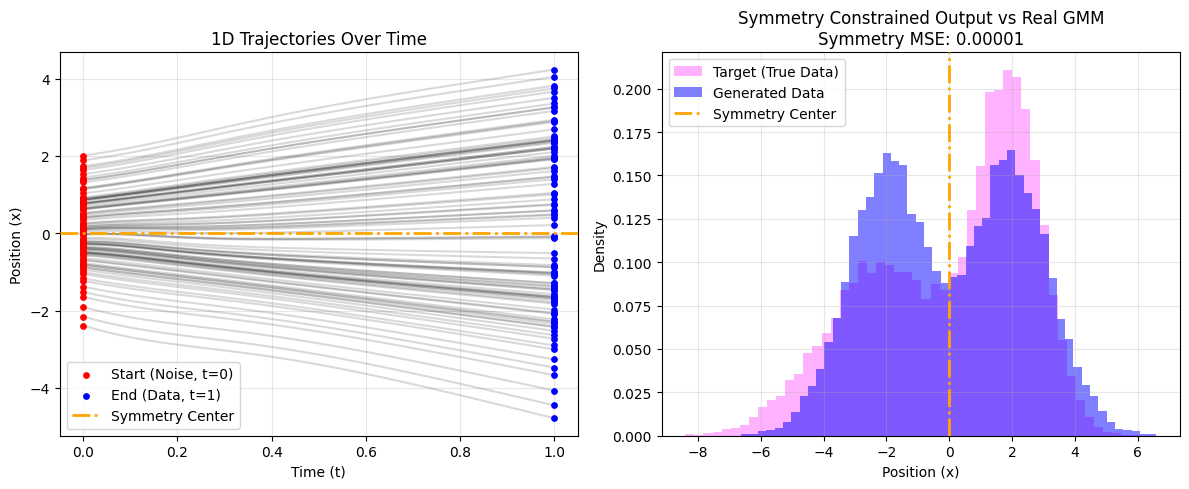

In [113]:
visualize_fm(
    sampled_data=sampled_data_guided4,
    true_data=real_data[:10000],
    title="Symmetry Constrained Output vs Real GMM",
    center_symmetry=static_center
)

# Distillation - Dynamic Symmetry Constraint

## create dataset for distillation

In [75]:
def create_conditional_symmetry_teacher_dataset(model, n_samples, center_range, steps=100, guidance_scale=5.0):
    """
    Generates a dataset where the entire batch is constrained to mirror a single,
    randomly sampled center point.
    """
    # Sample one random center for this entire batch
    center_c = torch.empty(1, device=device).uniform_(*center_range).item()
    print(f"Generating dataset for Symmetry Center: {center_c:.3f}")
    center_tensor = torch.full((n_samples, 1), center_c, device=device)

    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    all_x, all_t, all_v, all_x1_hat = [], [], [], []
    all_x1_dist_center = []
    all_targets = []

    model.eval()

    for i in range(steps):
        t = i * dt
        t_batch = torch.full((n_samples, 1), t, device=device)

        x = x.detach().requires_grad_(True)
        v = model(x, t_batch)

        # Predict destination
        x1_hat = x + (1 - t) * v

        # Batched Symmetry Loss
        x_sorted, _ = torch.sort(x1_hat.view(-1))
        half_N = n_samples // 2
        left_half = x_sorted[:half_N]
        right_half_reversed = x_sorted[-half_N:].flip(dims=[0])
        loss = torch.sum((left_half + right_half_reversed - 2 * center_c) ** 2)
        if n_samples % 2 != 0:
            loss += (x_sorted[half_N] - center_c) ** 2

        # calculate the gradient
        grad = torch.autograd.grad(loss, x)[0]

        # Apply guidance with Linear Schedule
        current_scale = t * guidance_scale
        v_guided = v - (current_scale * grad)

        # Feature Engineering: Distance from predicted destination to the center
        x1_dist_center = x1_hat - center_tensor

        # Collect data
        all_x.append(x.detach().cpu())
        all_t.append(t_batch.cpu())
        all_v.append(v.detach().cpu())
        all_x1_hat.append(x1_hat.detach().cpu())
        all_x1_dist_center.append(x1_dist_center.detach().cpu())
        all_targets.append(grad.detach().cpu())

        x = x.detach() + v_guided.detach() * dt

    # Teacher Baseline Metric (Mean Squared Error of the symmetry at t=1)
    x_final_sorted, _ = torch.sort(x.view(-1))
    left_final = x_final_sorted[:half_N]
    right_final_reversed = x_final_sorted[-half_N:].flip(dims=[0])
    # We use mean() here just for a readable human metric, not for gradients
    symmetry_mse = torch.mean((left_final + right_final_reversed - 2 * center_c) ** 2).item()

    # Pack Features
    features = {
        "x": torch.cat(all_x, dim=0),
        "t": torch.cat(all_t, dim=0),
        "v": torch.cat(all_v, dim=0),
        "x1_hat": torch.cat(all_x1_hat, dim=0),
        "center_c": center_tensor.cpu().repeat(steps, 1),
        "x1_dist_center": torch.cat(all_x1_dist_center, dim=0)
    }

    targets = torch.cat(all_targets, dim=0)

    return features, targets, symmetry_mse

In [76]:
all_features_list = []
all_targets_list = []
all_mse = []

for _ in range(10):
    f, t, mse = create_conditional_symmetry_teacher_dataset(
        model=model,
        n_samples=1000,
        center_range=dynamic_center_range,
        guidance_scale=2.0
    )
    all_features_list.append(f)
    all_targets_list.append(t)
    all_mse.append(mse)

# Concatenate them all together into one massive dataset for the student
features = {
    key: torch.cat([feat_dict[key] for feat_dict in all_features_list], dim=0)
    for key in all_features_list[0].keys()
}
targets = torch.cat(all_targets_list, dim=0)
baseline_mse = torch.tensor(all_mse).mean().item()

print(f"Total Student Training Samples: {targets.shape[0]}")
print(f"Teacher Baseline Final Symmetry MSE: {baseline_mse:.6f}")

Generating dataset for Symmetry Center: -0.122
Generating dataset for Symmetry Center: -2.839
Generating dataset for Symmetry Center: -1.109
Generating dataset for Symmetry Center: -1.311
Generating dataset for Symmetry Center: 0.142
Generating dataset for Symmetry Center: 1.656
Generating dataset for Symmetry Center: -0.914
Generating dataset for Symmetry Center: 2.256
Generating dataset for Symmetry Center: 0.446
Generating dataset for Symmetry Center: 2.112
Total Student Training Samples: 1000000
Teacher Baseline Final Symmetry MSE: 0.000022


In [77]:
# split train/val
total_samples = targets.shape[0]
split_ratio = 0.90 # 90% Train, 10% Val
split_idx = int(total_samples * split_ratio)

indices = torch.randperm(total_samples)
train_idx = indices[:split_idx]
val_idx = indices[split_idx:]

train_features = {k: v[train_idx] for k, v in features.items()}
val_features = {k: v[val_idx] for k, v in features.items()}

train_targets = targets[train_idx]
val_targets = targets[val_idx]

In [78]:
norm_stats = {}

for key in train_features.keys():
    mean = train_features[key].mean()
    std = train_features[key].std() + 1e-8  # prevents divide-by-zero

    norm_stats[key] = {'mean': mean, 'std': std}

    # Apply to BOTH Train and Val using the Train stats
    train_features[key] = (train_features[key] - mean) / std
    val_features[key] = (val_features[key] - mean) / std

for key, stats in norm_stats.items():
    print(f"{key}: mean={stats['mean']:.4f}, std={stats['std']:.4f}")

x: mean=0.0174, std=1.9845
t: mean=0.4949, std=0.2887
v: mean=-0.0104, std=1.6415
x1_hat: mean=0.0146, std=2.7095
center_c: mean=0.0312, std=1.5608
x1_dist_center: mean=-0.0166, std=2.4623


In [79]:
feature_names = list(train_features.keys())
print(f"Features loaded in this order: {feature_names}")

train_dataset = TensorDataset(
    *[train_features[feat] for feat in feature_names],
    train_targets
)

val_dataset = TensorDataset(
    *[val_features[feat] for feat in feature_names],
    val_targets
)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

Features loaded in this order: ['x', 't', 'v', 'x1_hat', 'center_c', 'x1_dist_center']
Train samples: 900000 | Val samples: 100000


## define the student model

In [82]:
class DynamicSymmetryStudentGuidanceMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, t, v, x1_hat, center_c, x1_dist_center):
        inputs = torch.cat([x, t, v, x1_hat, center_c, x1_dist_center], dim=-1)  # [batch_size, 6]
        return self.net(inputs)

## train the student model

In [ ]:
# Cache
dynamic_symmetry_student_model = DynamicSymmetryStudentGuidanceMLP().to(device)
state_dict = torch.load(f"1d_gmm_peaks_{peaks_str}_student_dynamic_symmetry_range_{center_range_str}.pth", map_location=device)
dynamic_symmetry_student_model.load_state_dict(state_dict)

<All keys matched successfully>

In [83]:
dynamic_symmetry_student_model = DynamicSymmetryStudentGuidanceMLP().to(device)
optimizer = torch.optim.Adam(dynamic_symmetry_student_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 25

dynamic_symmetry_student_model.train()
train_loss_list = []
val_loss_list = []

print("Starting Dynamic-Student Training...")

for epoch in tqdm(range(epochs)):
    dynamic_symmetry_student_model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = [b.to(device) for b in batch]

        features = batch[:-1]
        batch_target = batch[-1]

        optimizer.zero_grad()
        pred_grad = dynamic_symmetry_student_model(*features)
        loss = criterion(pred_grad, batch_target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    dynamic_symmetry_student_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = [b.to(device) for b in batch]

            features = batch[:-1]
            batch_target = batch[-1]

            pred_grad = dynamic_symmetry_student_model(*features)
            loss = criterion(pred_grad, batch_target)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_loss_list.append(avg_train_loss)
    val_loss_list.append(avg_val_loss)

    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

print("Distillation Complete!")

Starting Dynamic-Student Training...


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 0/25 | Train Loss: 2.103593 | Val Loss: 0.181173
Epoch 5/25 | Train Loss: 0.081202 | Val Loss: 0.088448
Epoch 10/25 | Train Loss: 0.018446 | Val Loss: 0.015957
Epoch 15/25 | Train Loss: 0.014242 | Val Loss: 0.011337
Epoch 20/25 | Train Loss: 0.012633 | Val Loss: 0.011297
Epoch 24/25 | Train Loss: 0.011331 | Val Loss: 0.010282
Distillation Complete!


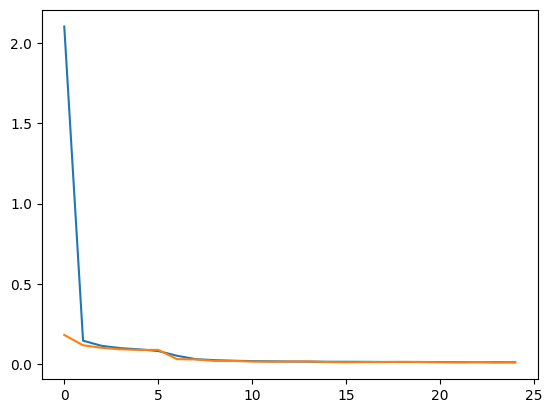

In [84]:
plt.plot(train_loss_list)
plt.plot(val_loss_list)
plt.show()

In [85]:
torch.save(dynamic_symmetry_student_model.state_dict(), f"1d_gmm_peaks_{peaks_str}_student_dynamic_symmetry_range_{center_range_str}.pth")

## sample using the student model

In [86]:
def sample_trajectory_dynamic_symmetry_student(model, student_model, center_c, feature_names, norm_stats, n_samples, steps=100, guidance_scale=5.0):
    """
    Dynamic distilled sampling for the Symmetry Constraint with Linear Guidance Scheduling.

    Args:
        center_c (float): The center point of symmetry.
        feature_names: A list of strings defining the EXACT order of features the student expects.
        norm_stats: The dictionary containing 'mean' and 'std' for all features and the 'target'.
    """
    x = torch.randn(n_samples, 1, device=device)
    dt = 1.0 / steps

    traj = [x.cpu()]
    model.eval()
    student_model.eval()

    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.full((n_samples, 1), t, device=device)

            # Base Model Predictions
            v = model(x, t_batch)
            x1_hat = x + (1 - t) * v

            # Compute Symmetry Features
            raw_features = {
                'x': x,
                't': t_batch,
                'v': v,
                'x1_hat': x1_hat,
                'center_c': torch.full((n_samples, 1), center_c, device=device),
                'x1_dist_center': x1_hat - center_c
            }

            # Normalize Inputs
            normalized_inputs = []
            for feat in feature_names:
                val = raw_features[feat]
                mean = norm_stats[feat]['mean']
                std = norm_stats[feat]['std']
                normalized_inputs.append((val - mean) / std)

            # Predict Normalized Gradient
            pred_grad = student_model(*normalized_inputs)

            # Apply Linear Guidance
            current_scale = t * guidance_scale
            v_guided = v - (current_scale * pred_grad)

            # Euler Step
            x = x + v_guided * dt

            traj.append(x.cpu())

    return torch.stack(traj).numpy()  # Final shape: [steps + 1, n_samples, 1]

In [90]:
active_symmetry_features = ['x', 't', 'v', 'x1_hat', 'center_c', 'x1_dist_center']

In [114]:
center = 0

sampled_data_guided_dynamic_symmetry_distilled = sample_trajectory_dynamic_symmetry_student(
    model=model,
    student_model=dynamic_symmetry_student_model,
    center_c=center,
    feature_names=active_symmetry_features,
    norm_stats=norm_stats,
    n_samples=100000,
    guidance_scale=2.0
)

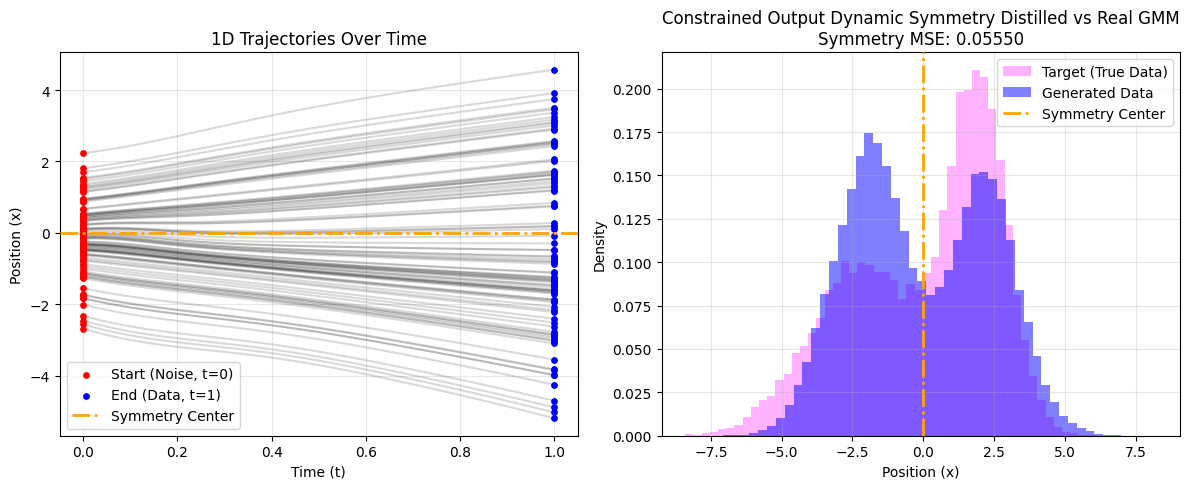

In [115]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_symmetry_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Symmetry Distilled vs Real GMM",
    center_symmetry=center
)

In [116]:
center = 1.5

sampled_data_guided_dynamic_symmetry_distilled = sample_trajectory_dynamic_symmetry_student(
    model=model,
    student_model=dynamic_symmetry_student_model,
    center_c=center,
    feature_names=active_symmetry_features,
    norm_stats=norm_stats,
    n_samples=100000,
    guidance_scale=2.0
)

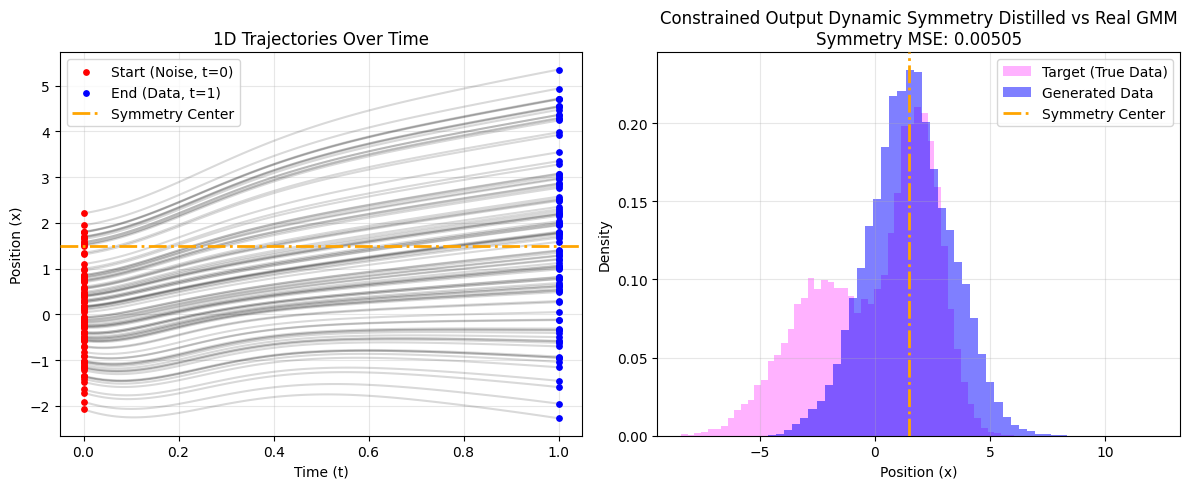

In [117]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_symmetry_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Symmetry Distilled vs Real GMM",
    center_symmetry=center
)

In [118]:
center = -1.5

sampled_data_guided_dynamic_symmetry_distilled = sample_trajectory_dynamic_symmetry_student(
    model=model,
    student_model=dynamic_symmetry_student_model,
    center_c=center,
    feature_names=active_symmetry_features,
    norm_stats=norm_stats,
    n_samples=100000,
    guidance_scale=2.0
)

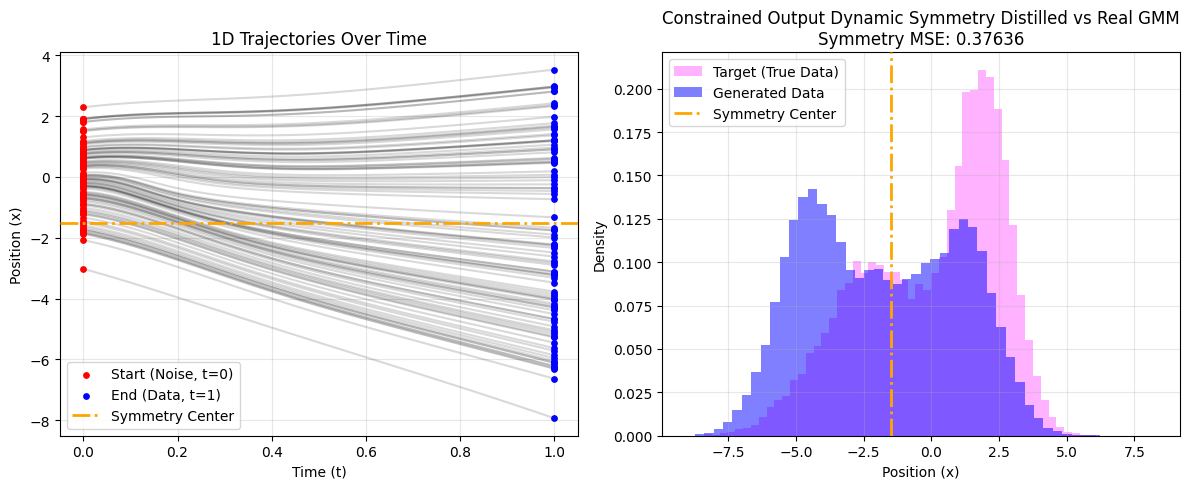

In [119]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_symmetry_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Symmetry Distilled vs Real GMM",
    center_symmetry=center
)

In [120]:
center = 2.5

sampled_data_guided_dynamic_symmetry_distilled = sample_trajectory_dynamic_symmetry_student(
    model=model,
    student_model=dynamic_symmetry_student_model,
    center_c=center,
    feature_names=active_symmetry_features,
    norm_stats=norm_stats,
    n_samples=100000,
    guidance_scale=2.0
)

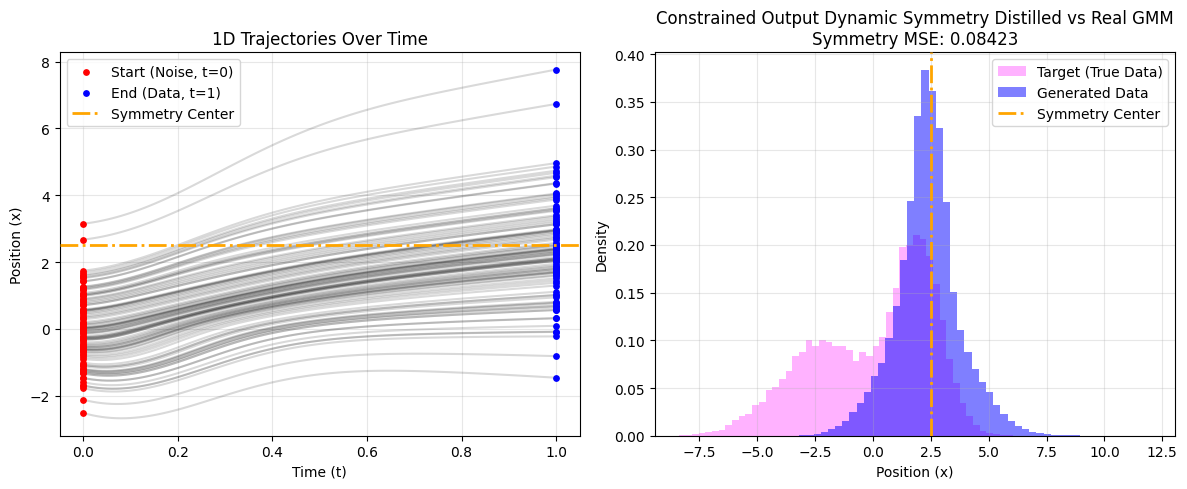

In [121]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_symmetry_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Symmetry Distilled vs Real GMM",
    center_symmetry=center
)

In [122]:
center = -2.5

sampled_data_guided_dynamic_symmetry_distilled = sample_trajectory_dynamic_symmetry_student(
    model=model,
    student_model=dynamic_symmetry_student_model,
    center_c=center,
    feature_names=active_symmetry_features,
    norm_stats=norm_stats,
    n_samples=100000,
    guidance_scale=2.0
)

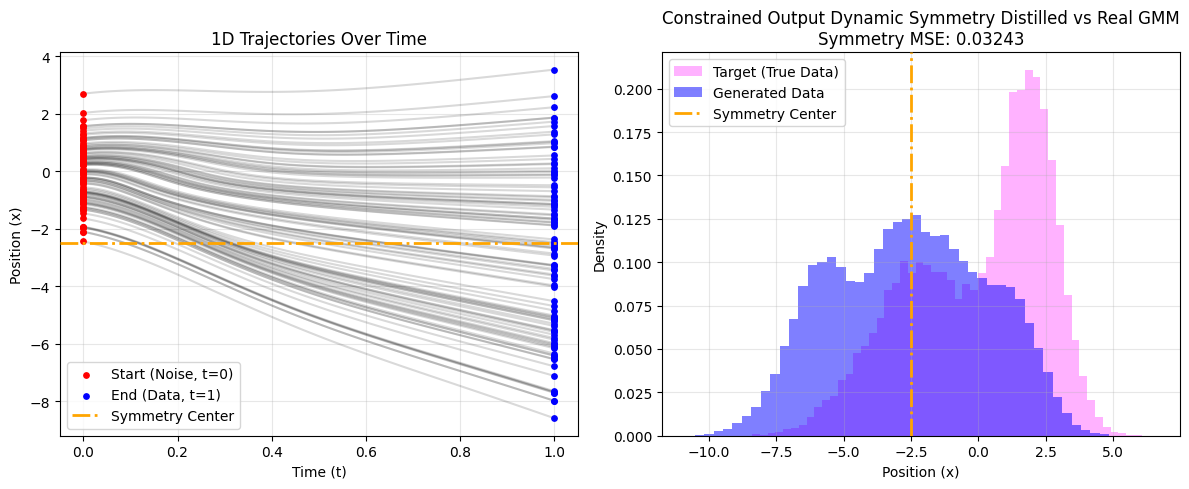

In [123]:
visualize_fm(
    sampled_data=sampled_data_guided_dynamic_symmetry_distilled,
    true_data=real_data[:10000],
    title="Constrained Output Dynamic Symmetry Distilled vs Real GMM",
    center_symmetry=center
)

In [124]:
criterion = nn.MSELoss()
importances = calculate_permutation_importance(dynamic_symmetry_student_model, val_loader, criterion, feature_names=active_symmetry_features)

Baseline MSE Loss: 0.010282

Shuffled x          | New Loss: 2.867439 | Error Increase: +2.857157
Shuffled t          | New Loss: 39.128269 | Error Increase: +39.117987
Shuffled v          | New Loss: 6.021474 | Error Increase: +6.011192
Shuffled x1_hat     | New Loss: 6.615414 | Error Increase: +6.605131
Shuffled center_c   | New Loss: 52.252579 | Error Increase: +52.242297
Shuffled x1_dist_center | New Loss: 7.211850 | Error Increase: +7.201568


Plot saved to student_feature_importance.png


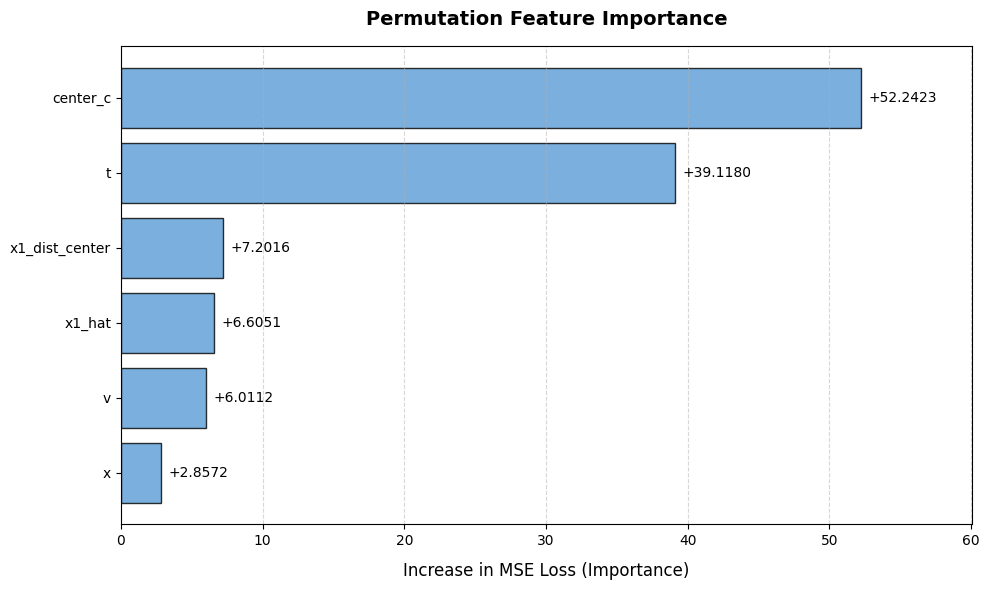

In [125]:
plot_feature_importance(importances)